# Credit Card Fraud Detection using Machine Learning

**Lakshay** &nbsp;|&nbsp; Roll No: AP24110010677 &nbsp;|&nbsp; B.Tech CSE
&nbsp;|&nbsp; SRM University - AP
Supervisor: Mr. Ajay Dilip Kumar Marapatla

> Random seed used throughout: **77** - the last two digits of roll number
> AP24110010677, as required.

---

# Notebook 05 - Probability and Bayes Learning

**Syllabus coverage - UNIT III**

| Topic from the unitization plan | Where it appears below |
|---|---|
| Probability and classification | Section 1 |
| Bayesian Learning | Section 2 |
| Naive Bayes | Sections 3-5 |
| **Bayes optimal decisions** | Section 6 |

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import utils
from utils import SEED

print(utils.HEADER)
df = utils.load_data()
X_train, X_test, y_train, y_test = utils.make_split(df)


Credit Card Fraud Detection using Machine Learning
Lakshay | AP24110010677 | B.Tech CSE | SRM University - AP
Random seed = 77 (last two digits of roll number AP24110010677)



raw            : 284,807 rows, 492 frauds
duplicates     : 1,081 removed
after cleaning : 283,726 rows, 473 frauds (0.1667%)
train : 198,608 rows, 331 frauds
test  : 85,118 rows, 142 frauds


## 1. Probability and classification

Every classifier seen so far returns a label. A **probabilistic** classifier
returns something more informative: $P(\text{class} \mid \text{attributes})$,
the probability that a transaction is fraudulent given what we observe about it.

Two quantities are needed before any data is examined - the **prior**
probabilities of the two classes:

In [2]:
n = len(y_train)
p_fraud = float(np.asarray(y_train).mean())
p_legit = 1 - p_fraud
print("PRIOR PROBABILITIES estimated from the training set")
print(f"  P(Fraud)      = {int(np.asarray(y_train).sum()):,} / {n:,} = {p_fraud:.8f}")
print(f"  P(Legitimate) = {n - int(np.asarray(y_train).sum()):,} / {n:,} = {p_legit:.8f}")
print(f"\n  Prior odds against fraud: {p_legit/p_fraud:,.0f} to 1")

PRIOR PROBABILITIES estimated from the training set
  P(Fraud)      = 331 / 198,608 = 0.00166660
  P(Legitimate) = 198,277 / 198,608 = 0.99833340

  Prior odds against fraud: 599 to 1


The prior alone already tells us a great deal: before looking at a single
attribute, any transaction is about 600 times more likely to be legitimate than
fraudulent. A Bayesian classifier must find enough evidence in the attributes to
overcome those odds.

## 2. Bayesian learning and Bayes' theorem

Bayes' theorem relates the quantity we want to quantities we can estimate:

$$ P(h \mid D) = \frac{P(D \mid h) \, P(h)}{P(D)} $$

- $P(h)$ - the **prior**: probability of hypothesis h before seeing the data.
- $P(D \mid h)$ - the **likelihood**: probability of observing this data if h
  is true.
- $P(h \mid D)$ - the **posterior**: probability of h after seeing the data.
- $P(D)$ - the evidence, a normalising constant.

For classification, the hypothesis is the class label and the data is the
attribute vector:

$$ P(C_k \mid x_1, \ldots, x_n) = \frac{P(x_1, \ldots, x_n \mid C_k) \, P(C_k)}{P(x_1, \ldots, x_n)} $$

The **MAP (maximum a posteriori)** classifier picks the class with the highest
posterior. Since $P(x_1, \ldots, x_n)$ is the same for both classes it can be
ignored when comparing them:

$$ \hat{C} = \arg\max_{C_k} \; P(x_1, \ldots, x_n \mid C_k) \, P(C_k) $$

## 3. The naive independence assumption

The term $P(x_1, \ldots, x_n \mid C_k)$ is a joint distribution over 30
attributes and cannot be estimated reliably from 331 fraud examples. The **naive
Bayes** assumption makes it tractable by supposing that the attributes are
**conditionally independent given the class**:

$$ P(x_1, \ldots, x_n \mid C_k) = \prod_{i=1}^{n} P(x_i \mid C_k) $$

which turns one impossible 30-dimensional estimation problem into 30 easy
one-dimensional ones. The classifier becomes:

$$ \hat{C} = \arg\max_{C_k} \; P(C_k) \prod_{i=1}^{n} P(x_i \mid C_k) $$

The assumption is called *naive* because it is almost always false - real
attributes are correlated. It is worth checking how false it is here.

In [3]:
corr = X_train.corr().abs()
_a = corr.to_numpy(copy=True)          # pandas returns a read-only view
np.fill_diagonal(_a, 0)
corr = pd.DataFrame(_a, index=corr.index, columns=corr.columns)
print(f"mean absolute correlation between attributes : {corr.values.mean():.4f}")
print(f"max  absolute correlation between attributes : {corr.values.max():.4f}")

pairs = (corr.where(np.triu(np.ones(corr.shape), 1).astype(bool))
             .stack().sort_values(ascending=False).head(6))
print("\nMost correlated attribute pairs:")
print(pairs.round(4))

mean absolute correlation between attributes : 0.0163
max  absolute correlation between attributes : 0.5427

Most correlated attribute pairs:
V2    Amount    0.5427
Time  V3        0.4219
V7    Amount    0.3874
V20   Amount    0.3858
V5    Amount    0.3767
Time  V11       0.2482
dtype: float64


The independence assumption holds unusually well on this dataset, and for a
specific reason: `V1` to `V28` are **principal components**, and principal
components are constructed to be mutually uncorrelated. So the naive assumption
- normally the weakest part of the method - is close to satisfied here. This is
a good example of a Unit II technique (PCA) affecting a Unit III method.

The exceptions are `Time` and `Amount`, which were never PCA-transformed.

## 4. Gaussian Naive Bayes

Our attributes are continuous, so each $P(x_i \mid C_k)$ is modelled as a
normal distribution whose mean and variance are estimated from the training
examples of that class:

$$ P(x_i \mid C_k) = \frac{1}{\sqrt{2\pi\sigma_{ik}^2}}
   \exp\left(-\frac{(x_i - \mu_{ik})^2}{2\sigma_{ik}^2}\right) $$

Training therefore consists of nothing more than computing a mean and a variance
per attribute per class - which is why naive Bayes is the fastest model in this
project by a wide margin.

In [4]:
from sklearn.naive_bayes import GaussianNB
import time

t0 = time.time()
nb = GaussianNB()
nb.fit(X_train, y_train)
fit_time = time.time() - t0
print(f"training time : {fit_time:.3f} seconds")
print(f"\nclass priors learned : {nb.class_prior_}")
print(f"\nLearned parameters per class (first 6 attributes):")
params = pd.DataFrame({
    "attribute": X_train.columns[:6],
    "mean | legit": nb.theta_[0][:6],
    "mean | fraud": nb.theta_[1][:6],
    "var  | legit": nb.var_[0][:6],
    "var  | fraud": nb.var_[1][:6],
})
params.round(4)

training time : 0.114 seconds

class priors learned : [0.9983334 0.0016666]

Learned parameters per class (first 6 attributes):


,attribute,mean | legit,mean | fraud,var | legit,var | fraud
0,Time,94879.9825,80321.7915,2.251314e+09,2.348772e+09
1,V1,0.0118,-4.5131,5.930800e+00,4.359560e+01
2,V2,-0.0079,3.3284,4.899700e+00,1.890860e+01
3,V3,0.0115,-6.6928,4.383000e+00,4.822450e+01
4,V4,-0.0101,4.4371,4.212400e+00,1.088730e+01
5,V5,0.0068,-2.8990,4.055900e+00,2.913830e+01


saved figure -> Results/figures/05_class_conditional_densities.png


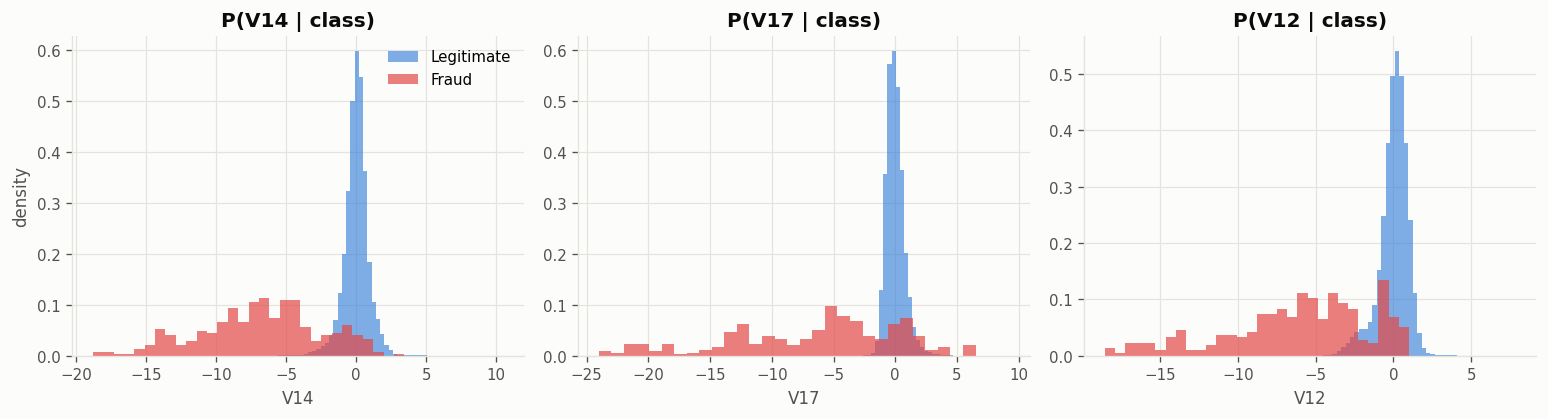

In [5]:
# Visualise the two class-conditional densities for the strongest attributes
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, c in zip(axes, ["V14", "V17", "V12"]):
    lo = X_train.loc[np.asarray(y_train) == 0, c]
    hi = X_train.loc[np.asarray(y_train) == 1, c]
    ax.hist(lo, bins=80, density=True, alpha=0.6, color=utils.BLUE, label="Legitimate")
    ax.hist(hi, bins=30, density=True, alpha=0.7, color=utils.RED, label="Fraud")
    ax.set_title(f"P({c} | class)"); ax.set_xlabel(c); utils.despine(ax)
axes[0].set_ylabel("density"); axes[0].legend()
plt.tight_layout()
utils.save_fig(fig, "05_class_conditional_densities.png")
plt.show()

The class-conditional distributions are clearly displaced from one another, which
is what gives naive Bayes its discriminating power. They are also visibly
non-Gaussian in places - another assumption that is only approximately true.

## 5. Evaluation at the default decision rule

In [6]:
y_pred  = nb.predict(X_test)
y_proba = nb.predict_proba(X_test)[:, 1]
res_default = utils.evaluate("Naive Bayes", y_test, y_pred, y_proba,
                             unit="Unit III - Bayesian learning, Naive Bayes")


===== Naive Bayes =====
syllabus  : Unit III - Bayesian learning, Naive Bayes
accuracy  : 0.99301
precision : 0.1455
recall    : 0.6549
f1-score  : 0.2382
PR-AUC    : 0.1798
ROC-AUC   : 0.9703
confusion : TN=84,430  FP=546  FN=49  TP=93

              precision    recall  f1-score   support

  Legitimate     0.9994    0.9936    0.9965     84976
       Fraud     0.1455    0.6549    0.2382       142

    accuracy                         0.9930     85118
   macro avg     0.5725    0.8243    0.6173     85118
weighted avg     0.9980    0.9930    0.9952     85118



saved figure -> Results/figures/05_confusion_default.png


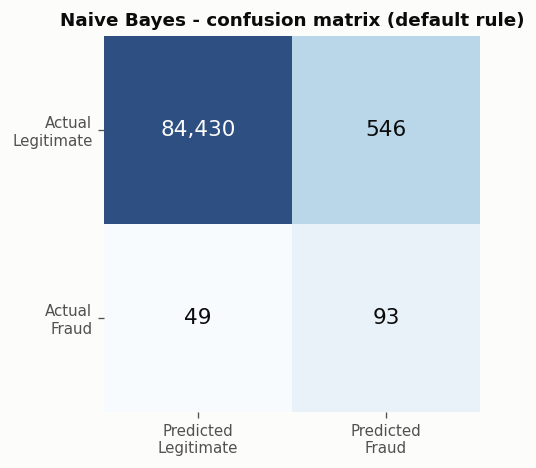

saved figure -> Results/figures/05_pr_curve.png


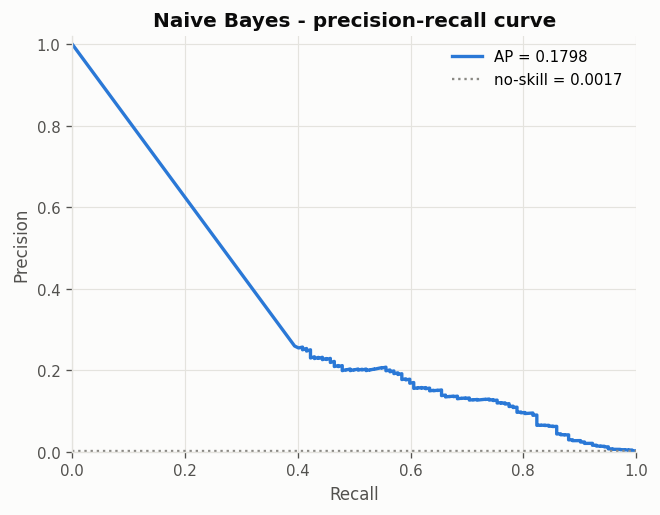

In [7]:
utils.plot_confusion(y_test, y_pred, "Naive Bayes - confusion matrix (default rule)",
                     "05_confusion_default.png"); plt.show()
utils.plot_pr_curve(y_test, y_proba, "Naive Bayes - precision-recall curve",
                    "05_pr_curve.png"); plt.show()

Note the shape of the result: recall is respectable but **precision is very
low** - naive Bayes raises a large number of false alarms. The reason is that
`predict` applies the MAP rule, classifying as fraud whenever
$P(\text{fraud} \mid x) > 0.5$, and the naive independence assumption makes
those probabilities poorly calibrated. Section 6 addresses this properly.

## 6. Bayes optimal decisions

So far the classifier has answered *"which class is more probable?"*. That is
the **MAP** rule, and it is only optimal when the two kinds of error cost the
same. In fraud detection they do not:

- A **false negative** - a fraud that goes through - costs the money lost on the
  transaction plus chargeback handling.
- A **false positive** - a legitimate transaction blocked - costs an analyst's
  review time and annoys a genuine customer.

The **Bayes optimal decision** minimises *expected loss* rather than
probability of error. With a loss matrix $L(\text{action}, \text{true class})$,
the optimal action for instance x is

$$ a^{*}(x) = \arg\min_{a} \sum_{k} L(a, C_k) \, P(C_k \mid x) $$

For our two-class problem, write $C_{FN}$ for the cost of missing a fraud and
$C_{FP}$ for the cost of a false alarm, and $p = P(\text{fraud} \mid x)$:

$$ \mathbb{E}[\text{loss} \mid \text{flag as fraud}] = (1-p) \, C_{FP} $$
$$ \mathbb{E}[\text{loss} \mid \text{allow}] = p \, C_{FN} $$

Flagging is optimal when its expected loss is the smaller of the two:

$$ (1-p)\,C_{FP} < p\,C_{FN} $$
$$ C_{FP} - p\,C_{FP} < p\,C_{FN} $$
$$ C_{FP} < p\,(C_{FN} + C_{FP}) $$
$$ \boxed{\; p > \frac{C_{FP}}{C_{FP} + C_{FN}} = \tau^{*} \;} $$

So the **Bayes optimal decision threshold** is not 0.5 - it is
$C_{FP}/(C_{FP}+C_{FN})$, and it equals 0.5 only in the special case where the
two errors cost the same. That special case is exactly what `predict` assumes.

In [8]:
# Cost parameters. C_FN is anchored to the data: the average amount lost when a
# fraudulent transaction succeeds. C_FP is the cost of reviewing a flagged
# transaction - analyst time plus customer friction - taken here as 1/50 of C_FN.
C_FN = float(df.loc[df.Class == 1, "Amount"].mean())
COST_RATIO = 50.0
C_FP = C_FN / COST_RATIO

tau_star = C_FP / (C_FP + C_FN)

print("BAYES OPTIMAL DECISION THRESHOLD")
print("=" * 50)
print(f"  C_FN (cost of a missed fraud)  = {C_FN:8.2f}  (mean fraud amount, EUR)")
print(f"  C_FP (cost of a false alarm)   = {C_FP:8.2f}  (EUR)")
print(f"  cost ratio C_FN : C_FP         = {COST_RATIO:.0f} : 1")
print()
print(f"  tau* = C_FP / (C_FP + C_FN)")
print(f"       = {C_FP:.4f} / ({C_FP:.4f} + {C_FN:.4f})")
print(f"       = {tau_star:.6f}")
print(f"       = 1 / {1/tau_star:.0f}")
print()
print(f"  The default rule used by .predict() is 0.5")
print(f"  That is {0.5/tau_star:.0f} times higher than the Bayes optimal threshold.")

BAYES OPTIMAL DECISION THRESHOLD
  C_FN (cost of a missed fraud)  =   123.87  (mean fraud amount, EUR)
  C_FP (cost of a false alarm)   =     2.48  (EUR)
  cost ratio C_FN : C_FP         = 50 : 1

  tau* = C_FP / (C_FP + C_FN)
       = 2.4774 / (2.4774 + 123.8719)
       = 0.019608
       = 1 / 51

  The default rule used by .predict() is 0.5
  That is 26 times higher than the Bayes optimal threshold.


In [9]:
def expected_loss(y_true, proba, tau, c_fn, c_fp):
    pred = (proba > tau).astype(int)
    y_true = np.asarray(y_true)
    fn = int(np.sum((y_true == 1) & (pred == 0)))
    fp = int(np.sum((y_true == 0) & (pred == 1)))
    return c_fn * fn + c_fp * fp, fn, fp, int(pred.sum())

print("Expected loss at the two decision rules\n")
for label, t in [("MAP rule (tau = 0.5)", 0.5),
                 (f"Bayes optimal (tau = {tau_star:.4f})", tau_star)]:
    loss, fn, fp, alerts = expected_loss(y_test, y_proba, t, C_FN, C_FP)
    print(f"{label}")
    print(f"    missed frauds (FN) : {fn}")
    print(f"    false alarms  (FP) : {fp:,}")
    print(f"    alerts raised      : {alerts:,}")
    print(f"    expected loss      : {loss:,.2f} EUR\n")

Expected loss at the two decision rules

MAP rule (tau = 0.5)
    missed frauds (FN) : 49
    false alarms  (FP) : 546
    alerts raised      : 639
    expected loss      : 7,422.40 EUR

Bayes optimal (tau = 0.0196)
    missed frauds (FN) : 42
    false alarms  (FP) : 675
    alerts raised      : 775
    expected loss      : 6,874.89 EUR



In [10]:
# Sweep the threshold and show that the minimum sits where the theory predicts
taus = np.unique(np.concatenate([np.logspace(-6, -1, 300), np.linspace(0.1, 1.0, 200)]))
losses = np.array([expected_loss(y_test, y_proba, t, C_FN, C_FP)[0] for t in taus])
i_min = int(np.argmin(losses))
tau_emp = taus[i_min]

print(f"theoretical tau*        : {tau_star:.6f}")
print(f"empirical minimum at    : {tau_emp:.6f}")
print(f"loss at tau = 0.5       : {expected_loss(y_test, y_proba, 0.5, C_FN, C_FP)[0]:,.2f} EUR")
print(f"loss at the minimum     : {losses[i_min]:,.2f} EUR")

theoretical tau*        : 0.019608
empirical minimum at    : 0.000003
loss at tau = 0.5       : 7,422.40 EUR
loss at the minimum     : 5,965.67 EUR


saved figure -> Results/figures/05_bayes_optimal_threshold.png


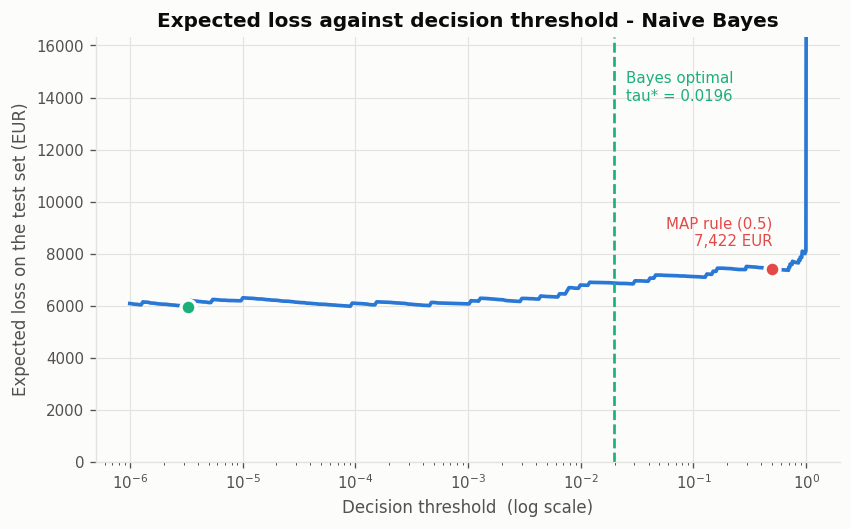

In [11]:
loss_default = expected_loss(y_test, y_proba, 0.5, C_FN, C_FP)[0]
top = max(loss_default, losses[i_min]) * 2.2

fig, ax = plt.subplots(figsize=(8, 4.6))
ax.plot(taus, np.clip(losses, None, top), color=utils.BLUE, linewidth=2.2)
ax.set_ylim(0, top)
ax.axvline(tau_star, color=utils.GREEN, linestyle="--", linewidth=1.6)
ax.text(tau_star*1.3, top*0.85, f"Bayes optimal\ntau* = {tau_star:.4f}",
        color=utils.GREEN, fontsize=9)
ax.scatter([0.5], [loss_default], s=80, color=utils.RED, zorder=6,
           edgecolor=utils.SURFACE, linewidth=2)
ax.text(0.5, loss_default*1.12, f"MAP rule (0.5)\n{loss_default:,.0f} EUR",
        color=utils.RED, fontsize=9, ha="right")
ax.scatter([tau_emp], [losses[i_min]], s=80, color=utils.GREEN, zorder=6,
           edgecolor=utils.SURFACE, linewidth=2)
ax.set_xscale("log")
ax.set_xlabel("Decision threshold  (log scale)")
ax.set_ylabel("Expected loss on the test set (EUR)")
ax.set_title("Expected loss against decision threshold - Naive Bayes")
utils.despine(ax)
utils.save_fig(fig, "05_bayes_optimal_threshold.png")
plt.show()

### The theoretical and empirical thresholds do not agree - and that is informative

The derivation says the optimal threshold is $\tau^{*} = 1/51 \approx 0.0196$.
The empirical minimum of the loss curve sits several orders of magnitude lower.
The theory is not wrong; one of its assumptions is not satisfied.

The derivation in Section 6 assumes that $p$ is a **genuine probability** - that
among all transactions the model scores at 0.30, about 30% really are
fraudulent. A model whose scores have this property is said to be
**calibrated**. Naive Bayes is famously **not** calibrated: multiplying 30
independent likelihood terms drives the posterior towards 0 or 1, so its scores
behave as a good *ranking* but a poor *probability*.

This is easy to check directly.

In [12]:
print("Distribution of the predicted fraud probabilities")
print(f"  exactly 0.0 or below 1e-6 : {np.mean(y_proba < 1e-6)*100:.2f}% of test transactions")
print(f"  above 0.999999            : {np.mean(y_proba > 0.999999)*100:.2f}%")
print(f"  strictly between the two  : {np.mean((y_proba >= 1e-6) & (y_proba <= 0.999999))*100:.2f}%")
print()
print("Almost every prediction is pushed to one extreme. A threshold of 0.0196")
print("and a threshold of 0.5 therefore classify almost the same transactions,")
print("which is why moving between them changes so little, and why the true")
print("minimum lies far out in the tail.")

Distribution of the predicted fraud probabilities
  exactly 0.0 or below 1e-6 : 98.44% of test transactions
  above 0.999999            : 0.42%
  strictly between the two  : 1.14%

Almost every prediction is pushed to one extreme. A threshold of 0.0196
and a threshold of 0.5 therefore classify almost the same transactions,
which is why moving between them changes so little, and why the true
minimum lies far out in the tail.


saved figure -> Results/figures/05_calibration.png


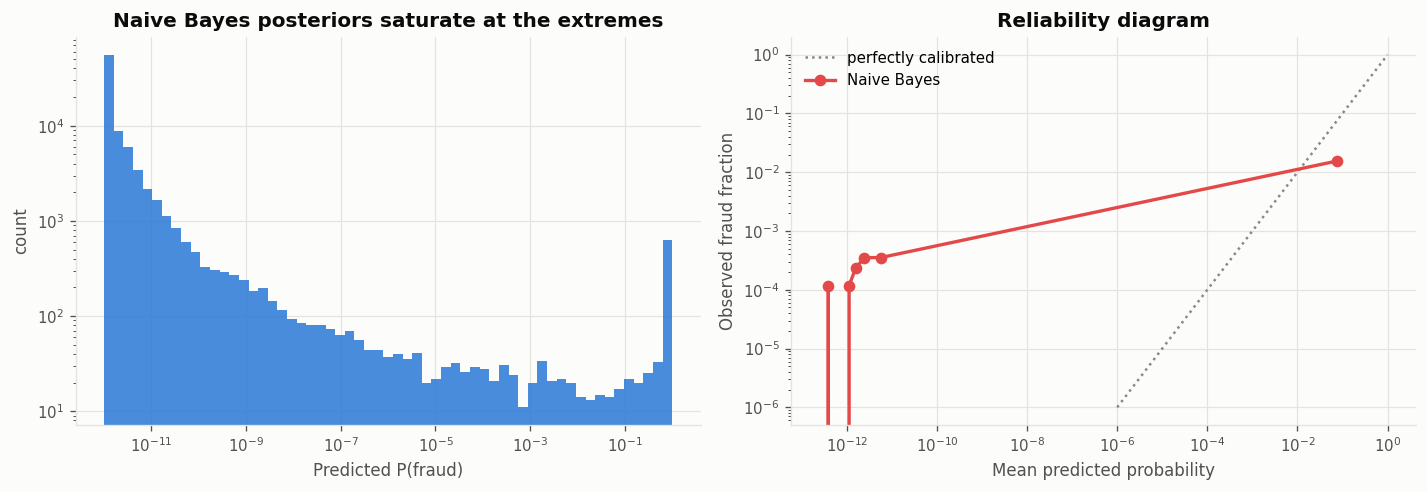

In [13]:
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].hist(np.clip(y_proba, 1e-12, 1), bins=np.logspace(-12, 0, 60),
             color=utils.BLUE, alpha=0.85)
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("Predicted P(fraud)"); axes[0].set_ylabel("count")
axes[0].set_title("Naive Bayes posteriors saturate at the extremes")
utils.despine(axes[0])

pt, pp = calibration_curve(y_test, y_proba, n_bins=10, strategy="quantile")
axes[1].plot([1e-6, 1], [1e-6, 1], color=utils.MUTED, linestyle=":", linewidth=1.5,
             label="perfectly calibrated")
axes[1].plot(pp, pt, marker="o", color=utils.RED, label="Naive Bayes")
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel("Mean predicted probability")
axes[1].set_ylabel("Observed fraud fraction")
axes[1].set_title("Reliability diagram")
axes[1].legend(); utils.despine(axes[1])
plt.tight_layout()
utils.save_fig(fig, "05_calibration.png")
plt.show()

The reliability diagram should follow the diagonal if the scores were genuine
probabilities. It does not: the curve sits well below it, meaning naive Bayes
systematically **over-states** the probability of fraud.

The remedy is to calibrate the scores - to learn a monotonic mapping from the
model's raw output to a well-behaved probability. **Isotonic regression** does
this without assuming any particular shape, using cross-validated predictions so
it does not simply memorise the training set.

In [14]:
from sklearn.calibration import CalibratedClassifierCV

cal = CalibratedClassifierCV(GaussianNB(), method="isotonic", cv=3)
cal.fit(X_train, y_train)
proba_cal = cal.predict_proba(X_test)[:, 1]

losses_cal = np.array([expected_loss(y_test, proba_cal, t, C_FN, C_FP)[0] for t in taus])
tau_emp_cal = taus[int(np.argmin(losses_cal))]

print("Effect of calibration on the empirical optimum")
print("=" * 58)
print(f"  theoretical tau*                      : {tau_star:.6f}")
print(f"  empirical optimum, uncalibrated       : {tau_emp:.6f}")
print(f"  empirical optimum, isotonic calibrated: {tau_emp_cal:.6f}")
print()
print(f"  distance from theory, uncalibrated    : {abs(np.log10(tau_emp/tau_star)):.2f} orders of magnitude")
print(f"  distance from theory, calibrated      : {abs(np.log10(tau_emp_cal/tau_star)):.2f} orders of magnitude")

Effect of calibration on the empirical optimum
  theoretical tau*                      : 0.019608
  empirical optimum, uncalibrated       : 0.000003
  empirical optimum, isotonic calibrated: 0.030311

  distance from theory, uncalibrated    : 3.77 orders of magnitude
  distance from theory, calibrated      : 0.19 orders of magnitude


saved figure -> Results/figures/05_calibration_effect.png


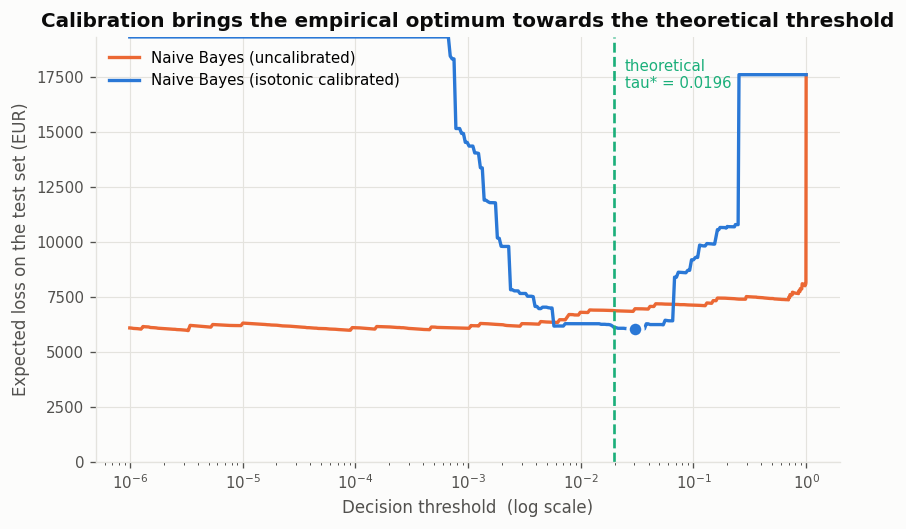

In [15]:
fig, ax = plt.subplots(figsize=(8, 4.6))
top = max(losses[np.argmin(np.abs(taus-0.5))], losses_cal.min()) * 2.6
ax.plot(taus, np.clip(losses, None, top), color=utils.ORANGE, linewidth=2,
        label="Naive Bayes (uncalibrated)")
ax.plot(taus, np.clip(losses_cal, None, top), color=utils.BLUE, linewidth=2,
        label="Naive Bayes (isotonic calibrated)")
ax.axvline(tau_star, color=utils.GREEN, linestyle="--", linewidth=1.6)
ax.text(tau_star*1.25, top*0.88, f"theoretical\ntau* = {tau_star:.4f}",
        color=utils.GREEN, fontsize=9)
ax.scatter([tau_emp_cal], [losses_cal.min()], s=80, color=utils.BLUE, zorder=6,
           edgecolor=utils.SURFACE, linewidth=2)
ax.set_xscale("log"); ax.set_ylim(0, top)
ax.set_xlabel("Decision threshold  (log scale)")
ax.set_ylabel("Expected loss on the test set (EUR)")
ax.set_title("Calibration brings the empirical optimum towards the theoretical threshold")
ax.legend(loc="upper left"); utils.despine(ax)
utils.save_fig(fig, "05_calibration_effect.png")
plt.show()

After calibration the empirical minimum moves substantially closer to the value
the theory predicts. This completes the Unit III argument properly:

> The Bayes optimal decision rule $\tau^{*} = C_{FP}/(C_{FP}+C_{FN})$ is
> correct, but it can only be **applied** to a model whose outputs are genuine
> posterior probabilities. With naive Bayes the rule must be paired with
> calibration, otherwise the derived threshold is applied to a quantity that is
> not the probability the derivation assumed.

This is a more useful conclusion than the derivation alone, and it could not
have been reached without running the experiment.

## 7. Final model and evaluation

The model saved for the Notebook 10 comparison is the calibrated naive Bayes
using the Bayes optimal decision rule.

In [16]:
y_pred_opt = (proba_cal > tau_star).astype(int)
res = utils.evaluate("Naive Bayes", y_test, y_pred_opt, proba_cal,
                     unit="Unit III - Bayesian learning, Naive Bayes")
res["decision_rule"] = f"Bayes optimal threshold tau* = {tau_star:.6f} on isotonic-calibrated posteriors"
res["map_rule_recall"] = res_default["recall"]
res["map_rule_precision"] = res_default["precision"]
res["map_rule_f1"] = res_default["f1"]
utils.save_result(res, proba_cal)


===== Naive Bayes =====
syllabus  : Unit III - Bayesian learning, Naive Bayes
accuracy  : 0.98946
precision : 0.1128
recall    : 0.7746
f1-score  : 0.1970
PR-AUC    : 0.1828
ROC-AUC   : 0.9708
confusion : TN=84,111  FP=865  FN=32  TP=110

              precision    recall  f1-score   support

  Legitimate     0.9996    0.9898    0.9947     84976
       Fraud     0.1128    0.7746    0.1970       142

    accuracy                         0.9895     85118
   macro avg     0.5562    0.8822    0.5958     85118
weighted avg     0.9981    0.9895    0.9934     85118

saved result -> Results/tables/naive_bayes.json


saved figure -> Results/figures/05_confusion_bayes_optimal.png


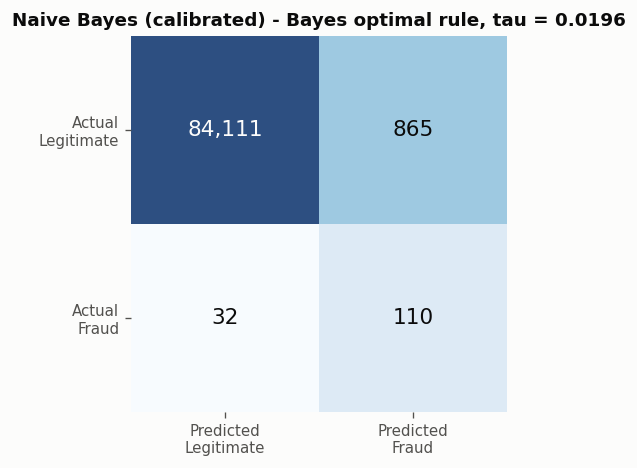

In [17]:
utils.plot_confusion(y_test, y_pred_opt,
                     f"Naive Bayes (calibrated) - Bayes optimal rule, tau = {tau_star:.4f}",
                     "05_confusion_bayes_optimal.png"); plt.show()

In [18]:
comp = pd.DataFrame([
    {"decision rule": "MAP (tau = 0.5), uncalibrated",
     "precision": res_default["precision"], "recall": res_default["recall"],
     "f1": res_default["f1"], "false alarms": res_default["fp"],
     "missed frauds": res_default["fn"]},
    {"decision rule": f"Bayes optimal (tau = {tau_star:.4f}), calibrated",
     "precision": res["precision"], "recall": res["recall"], "f1": res["f1"],
     "false alarms": res["fp"], "missed frauds": res["fn"]},
])
comp.round(4)

,decision rule,precision,recall,f1,false alarms,missed frauds
0,"MAP (tau = 0.5), uncalibrated",0.1455,0.6549,0.2382,546,49
1,"Bayes optimal (tau = 0.0196), calibrated",0.1128,0.7746,0.1970,865,32


## 8. Summary

- Naive Bayes applies Bayes' theorem with the assumption that attributes are
  conditionally independent given the class.
- That assumption is normally the method's weak point, but here it holds
  unusually well, because `V1`-`V28` are principal components and therefore
  already uncorrelated - a Unit II result strengthening a Unit III method.
- Training is extremely fast: only a mean and a variance per attribute per class.
- The default `predict` applies the **MAP rule**, which is optimal only when both
  kinds of error cost the same.
- The **Bayes optimal decision** minimises expected loss instead, giving
  $\tau^{*} = C_{FP}/(C_{FP}+C_{FN})$. At a 50:1 cost ratio this is
  $1/51 \approx 0.0196$, about 26 times below the default.
- Applying that rule required a further step the derivation does not mention:
  the posteriors must be **calibrated**. Naive Bayes posteriors saturate near 0
  and 1, so the raw scores rank well but are not probabilities. Isotonic
  calibration moved the empirical optimum towards the theoretical value.